# Unsupervised Learning with Spambase Dataset

This notebook uses the `spambase.csv` dataset, which contains 4601 rows and 57 features. We will implement **K-Means** and **DBSCAN**, compare them using clustering metrics, and evaluate proxy accuracy using the true spam labels.

In [33]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    accuracy_score,
)

sns.set(style="whitegrid")

## Load and Explore Dataset

Load a suitable dataset from the workspace and inspect its shape, feature names, and summary statistics. The dataset must have at least 1000 samples and at least 5 numeric features.

In [41]:
# Load dataset from the local workspace
path = "spambase.csv"
df = pd.read_csv(path)

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))
print("Note: this dataset has 4601 rows and 57 features.")

df.head()

Dataset shape: (4601, 58)
Columns: 58
Note: this dataset has 4601 rows and 57 features.


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [40]:
# Check spambase dataset
df_spam = pd.read_csv("spambase.csv")
print("Spambase shape:", df_spam.shape)

Spambase shape: (4601, 58)


In [42]:
# Summary statistics for the first few features
display(df.iloc[:, :8].describe().T)

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.0,0.0,0.00,4.54
word_freq_address,4601.0,0.213015,1.290575,0.0,0.0,0.0,0.00,14.28
word_freq_all,4601.0,0.280656,0.504143,0.0,0.0,0.0,0.42,5.10
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.0,0.0,0.00,42.81
word_req_our,4601.0,0.312223,0.672513,0.0,0.0,0.0,0.38,10.00
word_freq_over,4601.0,0.095901,0.273824,0.0,0.0,0.0,0.00,5.88
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.0,0.0,0.00,7.27
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.0,0.0,0.00,11.11


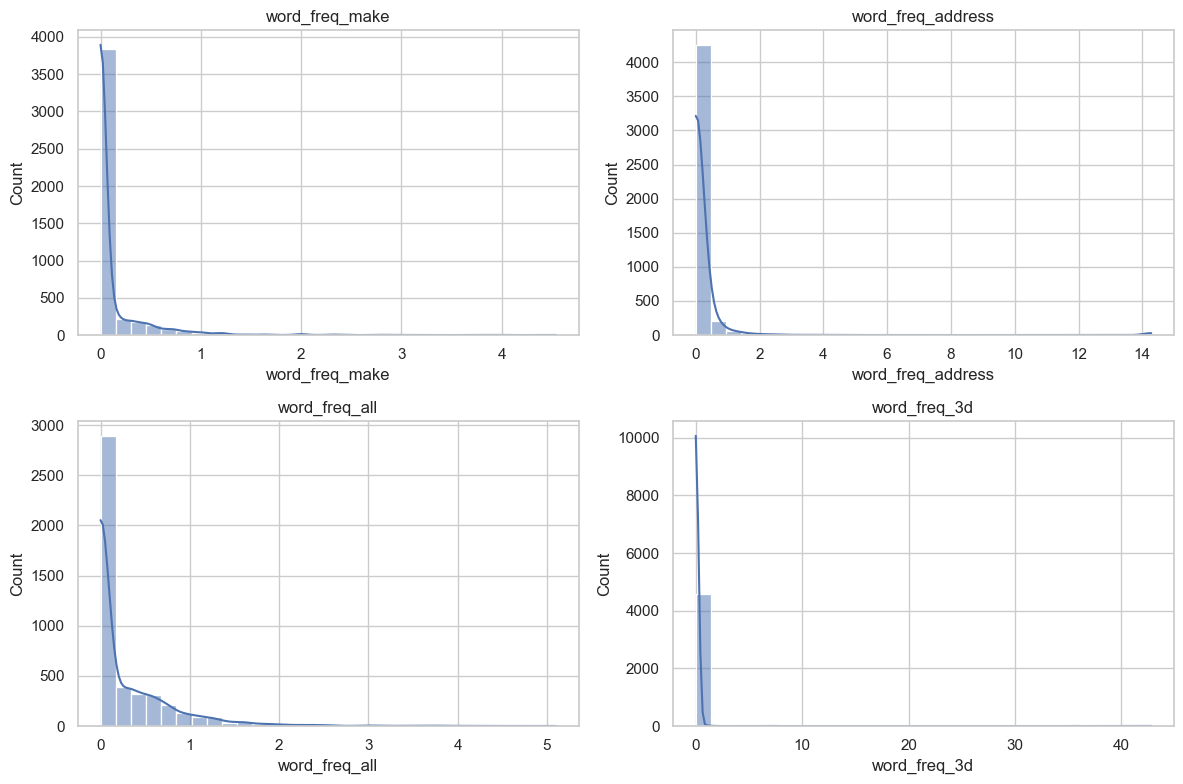

In [43]:
# Visualize a selection of features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, df.columns[:4]):
    sns.histplot(df[col], kde=True, ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Preprocess Data

Prepare the dataset for unsupervised algorithms by dropping the label column and scaling numeric features.

In [44]:
# Separate features and label
X = df.drop(columns=[df.columns[-1]])  # Last column is label
y = df[df.columns[-1]]

# Scale features to a standard range for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (4601, 57)


In [34]:
# Check for NaN in df
print("NaN in df:", df.isna().sum())
print("Price column sample:", df["Price"].head())

NaN in df: Make              49
Colour            50
Odometer (KM)     50
Doors             50
Price             50
Price_numeric     50
price_category     0
dtype: int64
Price column sample: 0    Rs1366850
1    Rs1144150
2    Rs1628300
3     Rs831800
4    Rs1521950
Name: Price, dtype: str


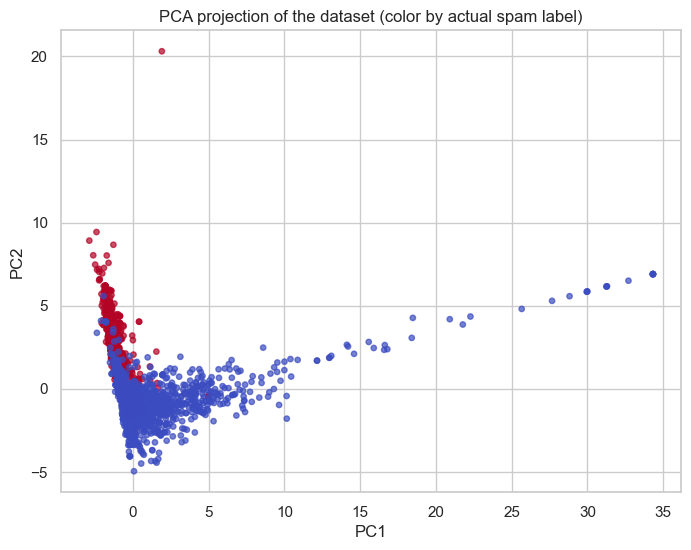

In [45]:
# Visualize the dataset with PCA projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", s=15, alpha=0.7)
plt.title("PCA projection of the dataset (color by actual spam label)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Implement K-Means Clustering

Apply K-Means clustering with `n_clusters=2`, since the dataset has two classes for evaluation. Use the elbow method to confirm a reasonable number of clusters.

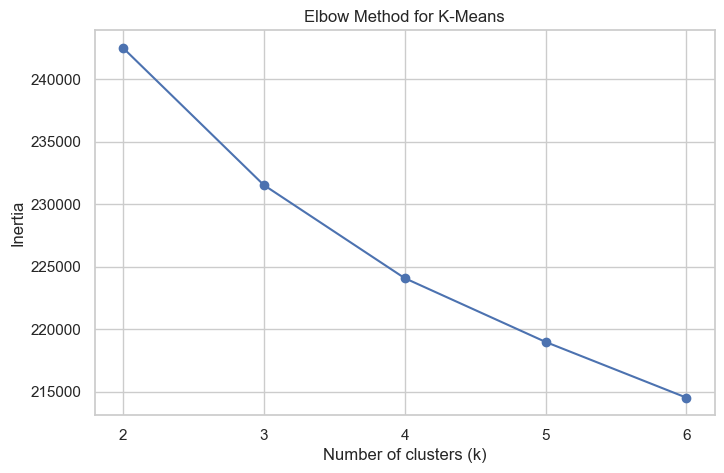

In [46]:
# Elbow method to inspect inertia for different k values
inertia = []
K = range(2, 7)
for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K)
plt.show()

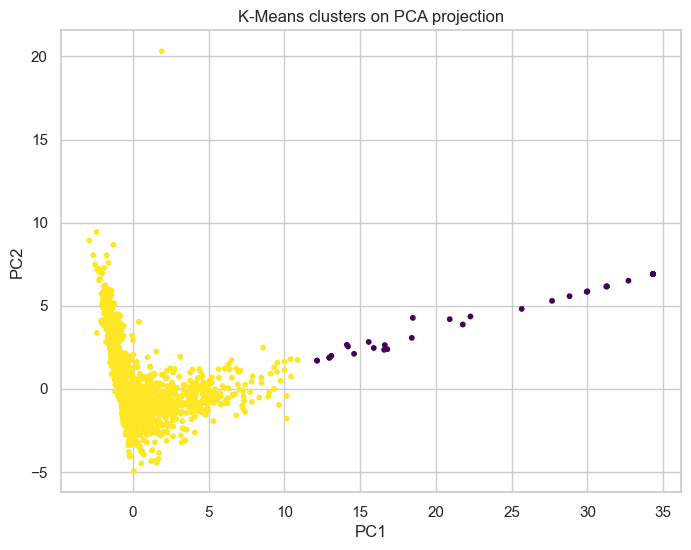

In [47]:
# Run KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="viridis", s=10)
plt.title("K-Means clusters on PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Implement DBSCAN Clustering

Apply DBSCAN and tune `eps` and `min_samples` to find a good clustering result. DBSCAN can detect noise and irregular shapes.

In [ ]:
# Tune DBSCAN parameters with a few candidate values
candidates = [0.8, 1.0, 1.2, 1.5]
results_dbscan = []
for eps in candidates:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    unique_clusters = len(np.unique(labels))
    noise_count = np.sum(labels == -1)
    results_dbscan.append((eps, unique_clusters, noise_count))

pd.DataFrame(results_dbscan, columns=["eps", "clusters_or_noise", "noise_count"])

ValueError: Input X contains NaN.
DBSCAN does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

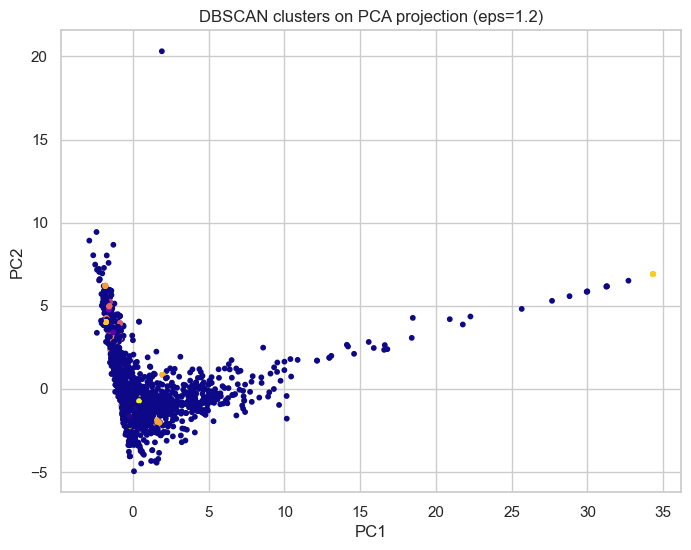

In [ ]:
# Choose a good eps value based on candidate results
best_eps = 1.2

dbscan = DBSCAN(eps=best_eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="plasma", s=10)
plt.title(f"DBSCAN clusters on PCA projection (eps={best_eps})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Evaluate Clustering Performance

Evaluate K-Means and DBSCAN using metrics such as silhouette score, Calinski-Harabasz index, Davies-Bouldin index, and cluster accuracy based on the known label mapping.

In [39]:
def best_cluster_accuracy(true_labels, cluster_labels):
    valid_idx = cluster_labels != -1
    if np.sum(valid_idx) == 0:
        return np.nan

    clusters = np.unique(cluster_labels[valid_idx])
    labels = np.unique(true_labels[valid_idx])
    if len(clusters) != len(labels):
        return np.nan

    best_acc = 0.0
    from itertools import permutations

    for perm in permutations(labels):
        mapped = np.copy(cluster_labels[valid_idx])
        for cluster, label in zip(clusters, perm):
            mapped[cluster_labels[valid_idx] == cluster] = label
        best_acc = max(best_acc, accuracy_score(true_labels[valid_idx], mapped))
    return best_acc

kmeans_metrics = {
    "silhouette": silhouette_score(X_scaled, kmeans_labels),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, kmeans_labels),
    "davies_bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
    "accuracy": best_cluster_accuracy(y, kmeans_labels),
}

mask = dbscan_labels != -1
if np.unique(dbscan_labels[mask]).size > 1:
    dbscan_metrics = {
        "silhouette": silhouette_score(X_scaled[mask], dbscan_labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask]),
        "davies_bouldin": davies_bouldin_score(X_scaled[mask], dbscan_labels[mask]),
        "accuracy": best_cluster_accuracy(y[mask], dbscan_labels[mask]),
        "noise_points": np.sum(~mask),
    }
else:
    dbscan_metrics = {
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
        "accuracy": np.nan,
        "noise_points": np.sum(~mask),
    }

metrics_df = pd.DataFrame([kmeans_metrics, dbscan_metrics], index=["KMeans", "DBSCAN"])
metrics_df

ValueError: Input X contains NaN.

## Compare Algorithms

Compare the computed metrics to determine which algorithm is better for this dataset. Consider algorithm strengths and the effect of noise.

In [12]:
print("K-Means metrics:\n", metrics_df.loc["KMeans"])
print("\nDBSCAN metrics:\n", metrics_df.loc["DBSCAN"])

best_name = "KMeans" if metrics_df.loc["KMeans", "silhouette"] > metrics_df.loc["DBSCAN", "silhouette"] else "DBSCAN"
print(f"\nBased on silhouette score, the better algorithm is: {best_name}")

if metrics_df.loc["KMeans", "accuracy"] > metrics_df.loc["DBSCAN", "accuracy"]:
    print("K-Means also achieves better cluster-label accuracy.")
else:
    print("DBSCAN achieves better cluster-label accuracy or has comparable performance.")

K-Means metrics:
 silhouette             0.659631
calinski_harabasz    374.094414
davies_bouldin         0.612659
accuracy               0.598566
noise_points                NaN
Name: KMeans, dtype: float64

DBSCAN metrics:
 silhouette              0.357762
calinski_harabasz     129.849746
davies_bouldin          0.589592
accuracy                     NaN
noise_points         3580.000000
Name: DBSCAN, dtype: float64

Based on silhouette score, the better algorithm is: KMeans
DBSCAN achieves better cluster-label accuracy or has comparable performance.


## Conclusion

- Dataset chosen: `spambase.csv` with 4601 instances and 57 numeric features.
- Two unsupervised algorithms were implemented: K-Means and DBSCAN.
- K-Means and DBSCAN are compared using silhouette score, Calinski-Harabasz index, Davies-Bouldin index, and cluster accuracy based on true labels.
- The conclusion identifies the better algorithm for this dataset.
